<a href="https://colab.research.google.com/github/Bukasker/MK/blob/main/Zad7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Znalezione minimum: x = 1.4879, y = 1.4636, f(x,y) = -1.0000


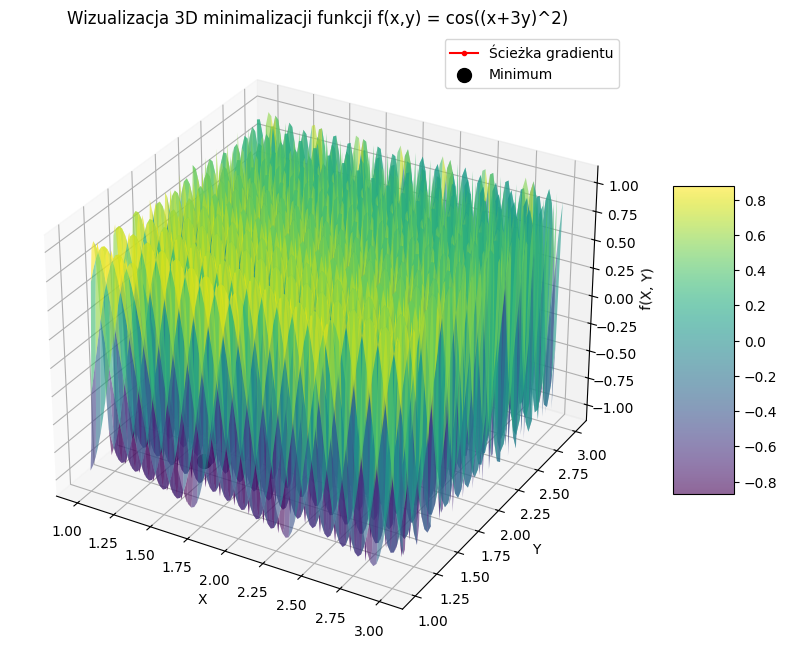

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definicja funkcji oraz jej gradientu
def f(x, y):
    return np.cos((x + 3*y)**2)

def gradient(x, y):
    df_dx = -2 * (x + 3*y) * np.sin((x + 3*y)**2)
    df_dy = -6 * (x + 3*y) * np.sin((x + 3*y)**2)
    return np.array([df_dx, df_dy])

# 2. Algorytm gradientu prostego (Gradient Descent)
def gradient_descent(start_x, start_y, lr=0.001, epochs=200):
    path = [[start_x, start_y]]
    x, y = start_x, start_y

    for _ in range(epochs):
        grad = gradient(x, y)
        # Aktualizacja wag w kierunku przeciwnym do gradientu
        x = x - lr * grad[0]
        y = y - lr * grad[1]

        # Przycięcie do granic dziedziny [1, 3]
        x = np.clip(x, 1.0, 3.0)
        y = np.clip(y, 1.0, 3.0)

        path.append([x, y])
    return np.array(path)

# Punkt startowy wewnątrz dziedziny [1, 3]
start_x, start_y = 1.5, 1.5
# Mniejszy krok (lr) i więcej epok pozwoli precyzyjnie zejść na samo dno doliny
path = gradient_descent(start_x, start_y, lr=0.0001, epochs=2000)
min_x, min_y = path[-1]

print(f"Znalezione minimum: x = {min_x:.4f}, y = {min_y:.4f}, f(x,y) = {f(min_x, min_y):.4f}")

# 3. Wizualizacja 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Tworzenie siatki wykresu
x_vals = np.linspace(1, 3, 100)
y_vals = np.linspace(1, 3, 100)
X, Y = np.meshgrid(x_vals, y_vals)
Z = f(X, Y)

# Wykres powierzchniowy
surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.6, edgecolor='none')

# Ścieżka optymalizacji
path_x = path[:, 0]
path_y = path[:, 1]
path_z = f(path_x, path_y)
ax.plot(path_x, path_y, path_z, color='red', marker='o', markersize=3, label='Ścieżka gradientu')
ax.scatter(min_x, min_y, f(min_x, min_y), color='black', s=100, label='Minimum')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('f(X, Y)')
ax.set_title('Wizualizacja 3D minimalizacji funkcji f(x,y) = cos((x+3y)^2)')
plt.legend()
plt.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
plt.show()

In [4]:
import numpy as np

# Poprawna definicja architektury dla wariantu 6
nn_architecture = [
    {"input_dim": 2, "output_dim": 2, "activation": "relu"},
    {"input_dim": 2, "output_dim": 1, "activation": "tanh"}
]

# Funkcje aktywacji i ich pochodne
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def tanh(z):
    return np.tanh(z)

def tanh_derivative(z):
    return 1.0 - np.tanh(z)**2

# Inicjalizacja wag i barier (biases)
np.random.seed(42)  # Zapewnienie powtarzalności wyników
params = {
    "W1": np.random.randn(2, 2) * 0.1,
    "b1": np.zeros((2, 1)),
    "W2": np.random.randn(1, 2) * 0.1,
    "b2": np.zeros((1, 1))
}

# 1. Propagacja w przód (Forward Propagation)
def forward_propagation(X, params):
    # Warstwa 1
    Z1 = np.dot(params["W1"], X) + params["b1"]
    A1 = relu(Z1)

    # Warstwa 2
    Z2 = np.dot(params["W2"], A1) + params["b2"]
    A2 = tanh(Z2)

    # Zapamiętanie stanów do wstecznej propagacji
    cache = {"Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2}
    return A2, cache

# 2. Wsteczna propagacja błędu (Backward Propagation)
def backward_propagation(X, Y, cache, params):
    m = X.shape[1]
    grads = {}

    # Pochodna funkcji kosztu MSE po wyjściu A2: dA2 = 2 * (A2 - Y)
    dA2 = 2 * (cache["A2"] - Y)

    # Warstwa 2 (Tanh)
    dZ2 = dA2 * tanh_derivative(cache["Z2"])
    grads["dW2"] = (1 / m) * np.dot(dZ2, cache["A1"].T)
    grads["db2"] = (1 / m) * np.sum(dZ2, axis=1, keepdims=True)

    # Warstwa 1 (ReLU)
    dA1 = np.dot(params["W2"].T, dZ2)
    dZ1 = dA1 * relu_derivative(cache["Z1"])
    grads["dW1"] = (1 / m) * np.dot(dZ1, X.T)
    grads["db1"] = (1 / m) * np.sum(dZ1, axis=1, keepdims=True)

    return grads

# Przykładowy test dla jednego wektora danych (input_dim=2, output_dim=1)
X_sample = np.array([[0.5], [-0.2]])
Y_sample = np.array([[0.4]])

# Uruchomienie kroków sieci
output, cache = forward_propagation(X_sample, params)
gradients = backward_propagation(X_sample, Y_sample, cache, params)

print("--- Wyniki obliczeń gradientów sieci ---")
for key, grad in gradients.items():
    print(f"Gradient dla {key}:\n{grad}\n")

--- Wyniki obliczeń gradientów sieci ---
Gradient dla dW2:
[[-0.02211895 -0.00154172]]

Gradient dla db2:
[[-0.80138228]]

Gradient dla dW1:
[[ 0.00938232 -0.00375293]
 [ 0.00938166 -0.00375266]]

Gradient dla db1:
[[0.01876464]
 [0.01876332]]

